# Day 08. Exercise 05
# Clustering

## 0. Imports

In [754]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [755]:
df = pd.read_csv('data/regression.csv')

print(f"Размер: {df.shape}")
print(df.head())

Размер: (29, 4)
       uid  num_commits  pageviews   AVG(diff)
0   user_1           62       28.0  -64.400000
1  user_10           20       89.0  -74.800000
2  user_14           61      143.0 -159.000000
3  user_17           51       47.0  -61.600000
4  user_18            5        3.0   -5.666667


In [756]:
df.drop('pageviews', axis = 1, inplace = True)

df.head()

,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


In [757]:
df_clustering = df[['num_commits', 'AVG(diff)']]

## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

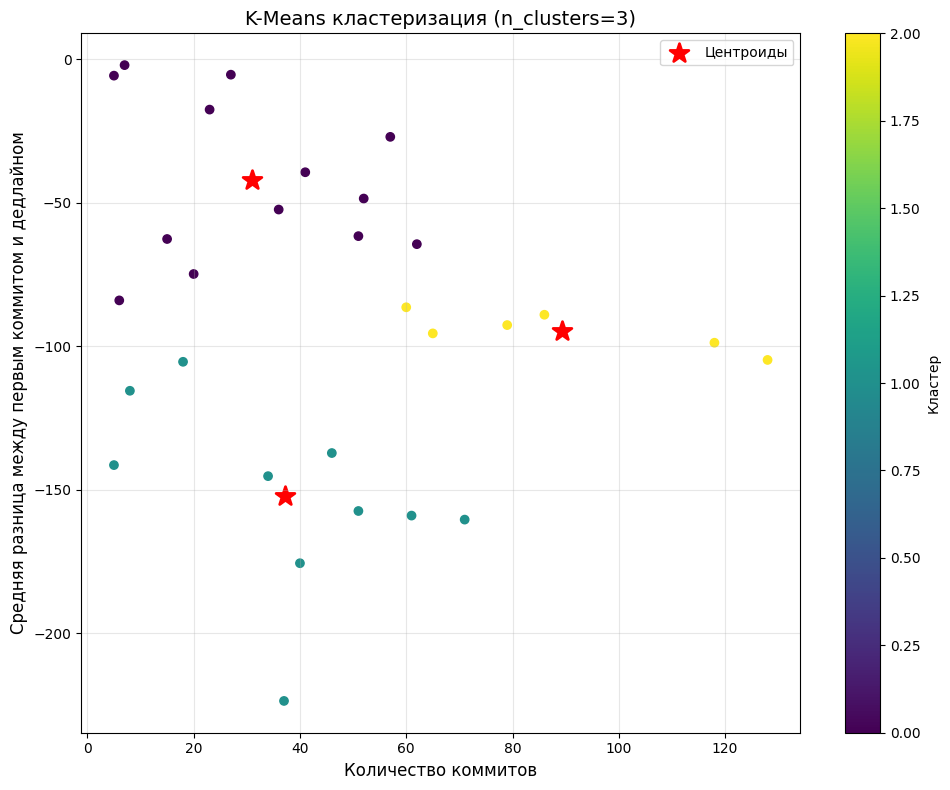

In [758]:
kmeans_3 = KMeans(n_clusters=3, random_state=21)
labels_3 = kmeans_3.fit_predict(df_clustering)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(df_clustering['num_commits'], df_clustering['AVG(diff)'], c=labels_3)
plt.scatter(kmeans_3.cluster_centers_[:, 0], kmeans_3.cluster_centers_[:, 1],
            c='red', marker='*', s=200, linewidth=2, label='Центроиды')
plt.xlabel('Количество коммитов', fontsize=12)
plt.ylabel('Средняя разница между первым коммитом и дедлайном', fontsize=12)
plt.title('K-Means кластеризация (n_clusters=3)', fontsize=14)
plt.legend()
plt.colorbar(scatter, label='Кластер')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

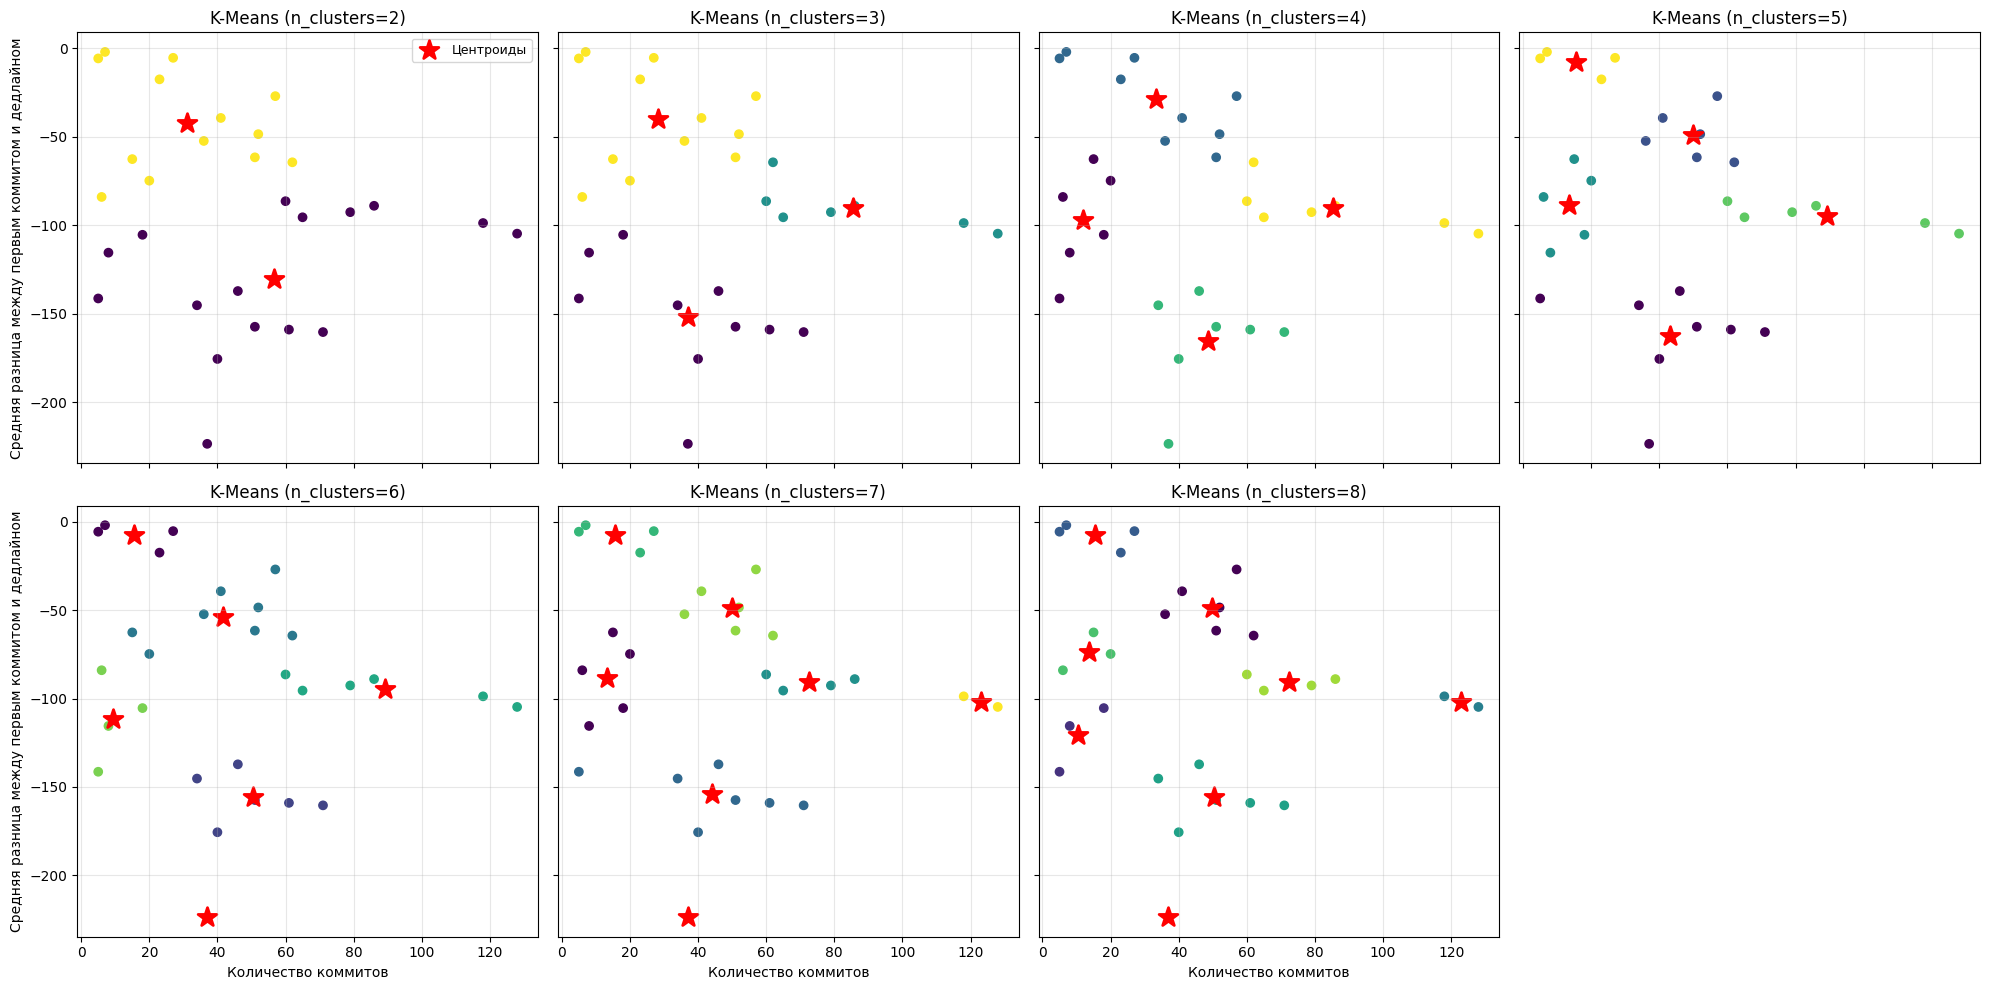

In [759]:
k_values = range(2, 10)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

for i, k in enumerate(k_values):
    ax = axes.flatten()[i]
    row, col = divmod(i, 4)

    kmeans = KMeans(n_clusters=k, random_state=21, n_init=10)
    labels = kmeans.fit_predict(df_clustering)

    ax.scatter(df_clustering['num_commits'], df_clustering['AVG(diff)'], c=labels)
    ax.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
               c='red', marker='*', s=200, linewidth=2, label='Центроиды')
    ax.set_title(f'K-Means (n_clusters={k})', fontsize=12)
    ax.grid(True, alpha=0.3)

    if col == 0:
        ax.set_ylabel('Средняя разница между первым коммитом и дедлайном', fontsize=10)
    if row == 1:
        ax.set_xlabel('Количество коммитов', fontsize=10)

axes[1, 3].set_visible(False)
axes[0, 0].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [760]:
silhouette_scores = []

for k in k_values:
    labels = KMeans(n_clusters=k, random_state=21, n_init=10).fit_predict(df_clustering)
    score = silhouette_score(df_clustering, labels)
    silhouette_scores.append(score)
    print(f"n_clusters={k}: Silhouette={score}")

n_clusters=2: Silhouette=0.41787451607810133
n_clusters=3: Silhouette=0.43901709571532954
n_clusters=4: Silhouette=0.44414602561947886
n_clusters=5: Silhouette=0.4760630149229996
n_clusters=6: Silhouette=0.44572484120013867
n_clusters=7: Silhouette=0.4964107297576806
n_clusters=8: Silhouette=0.50779855565622
n_clusters=9: Silhouette=0.47576869039147557


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

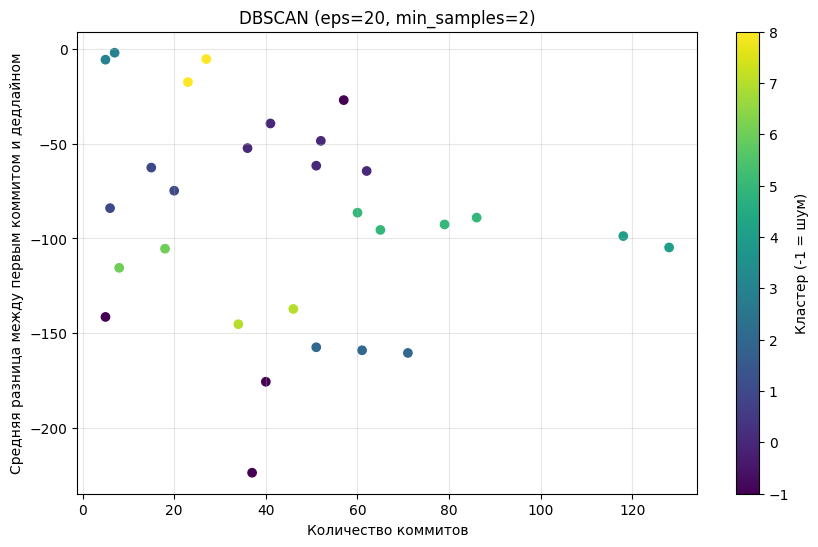

In [761]:
labels_dbscan = DBSCAN(eps=20, min_samples=2).fit_predict(df_clustering)

plt.figure(figsize=(10, 6))

plt.scatter(df_clustering['num_commits'], df_clustering['AVG(diff)'],
            c=labels_dbscan, cmap='viridis')
plt.title('DBSCAN (eps=20, min_samples=2)')
plt.xlabel('Количество коммитов')
plt.ylabel('Средняя разница между первым коммитом и дедлайном')
plt.colorbar(label='Кластер (-1 = шум)')
plt.grid(True, alpha=0.3)

plt.show()

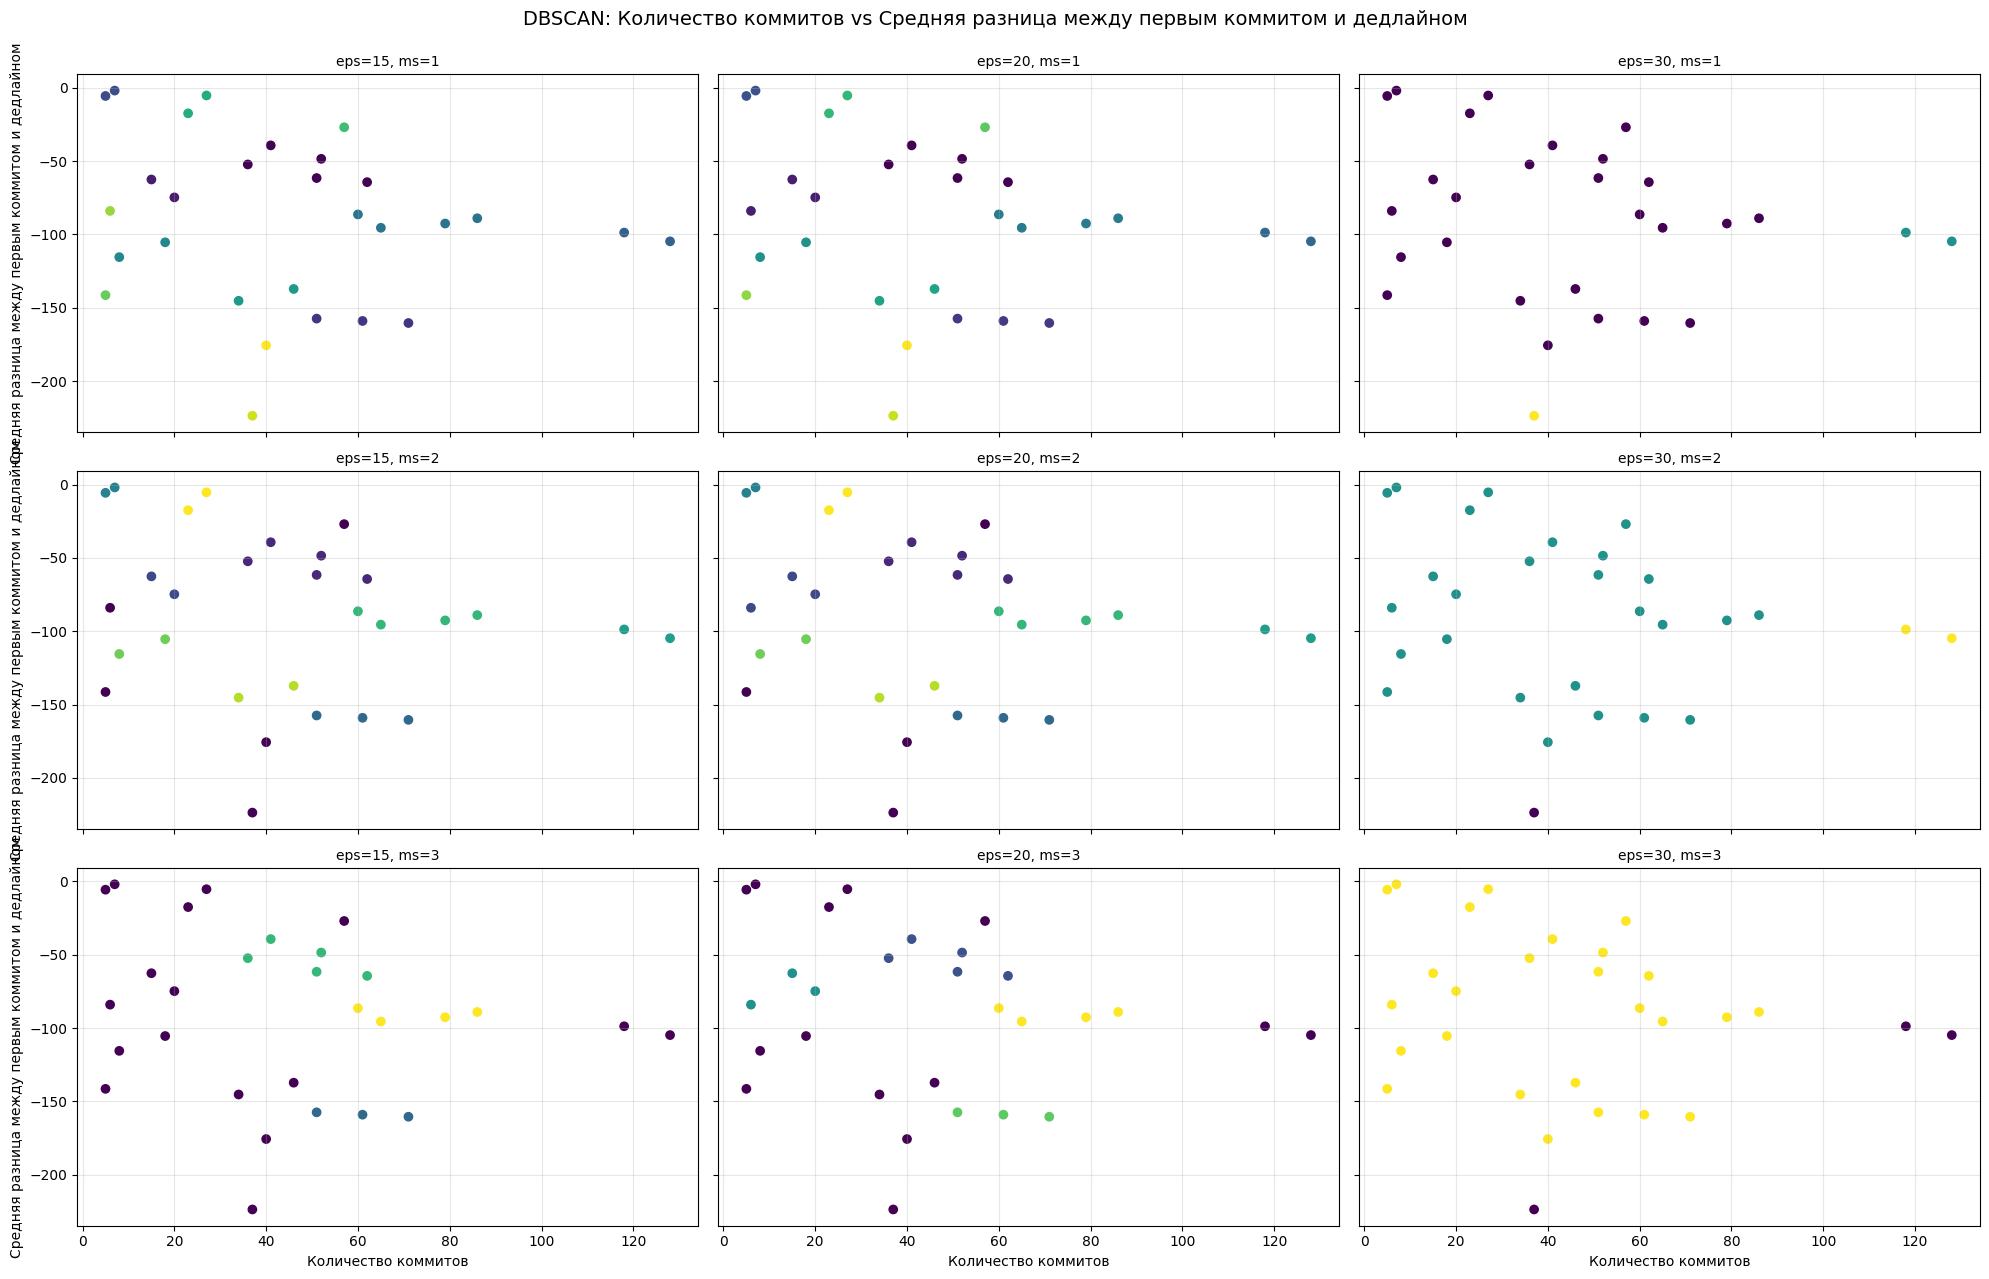

In [762]:
eps_grid = [15, 20, 30]
min_samples_grid = [1, 2, 3]

dbscan_grid_results = []

n_rows = len(min_samples_grid)
n_cols = len(eps_grid)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 13), sharex=True, sharey=True)

for i, ms in enumerate(min_samples_grid):
    for j, eps in enumerate(eps_grid):
        ax     = axes[i, j]
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(df_clustering)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()
        mask       = labels != -1
        score      = silhouette_score(df_clustering[mask], labels[mask]) if n_clusters > 1 and mask.sum() > 1 else float('nan')

        dbscan_grid_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters, 'silhouette_score': score
        })

        scatter = ax.scatter(
            df_clustering['num_commits'],
            df_clustering['AVG(diff)'],
            c=labels, cmap='viridis'
        )
        ax.set_title(f'eps={eps}, ms={ms}', fontsize=10)
        ax.grid(True, alpha=0.3)

        if j == 0:
            ax.set_ylabel('Средняя разница между первым коммитом и дедлайном', fontsize=10)
        if i == n_rows - 1:
            ax.set_xlabel('Количество коммитов', fontsize=10)

plt.suptitle('DBSCAN: Количество коммитов vs Средняя разница между первым коммитом и дедлайном\n', fontsize=14)
plt.tight_layout()
plt.show()


In [763]:
print(f"{'eps'} {'min_samples'} {'кластеры'} {'silhouette'}")
print("-" * 45)

for r in dbscan_grid_results:
    print(f"{r['eps']} {r['min_samples']} {r['n_clusters']} {r['silhouette_score']}")

eps min_samples кластеры silhouette
---------------------------------------------
15 1 14 0.39698929034198316
20 1 13 0.4322483665424573
30 1 3 0.19881722125199422
15 2 9 0.5553952578355401
20 2 9 0.5441859666389783
30 2 2 0.26480387526325777
15 3 3 0.6405544053495466
20 3 4 0.6010852046755665
30 3 1 nan


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

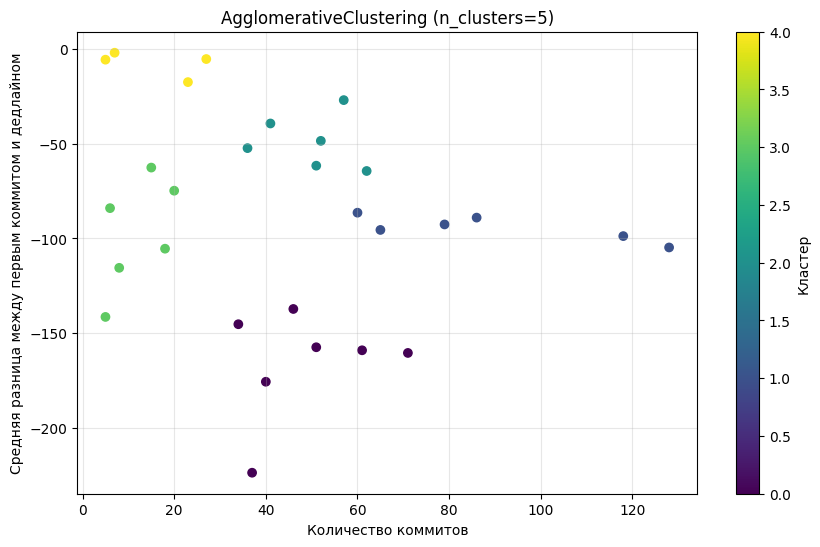

In [764]:
labels_agg_5 = AgglomerativeClustering(n_clusters=5, linkage='ward').fit_predict(df_clustering)

plt.figure(figsize=(10, 6))

plt.scatter(df_clustering['num_commits'], df_clustering['AVG(diff)'],
            c=labels_agg_5, cmap='viridis')
plt.title('AgglomerativeClustering (n_clusters=5)')
plt.xlabel('Количество коммитов')
plt.ylabel('Средняя разница между первым коммитом и дедлайном')
plt.colorbar(label='Кластер')
plt.grid(True, alpha=0.3)

plt.show()

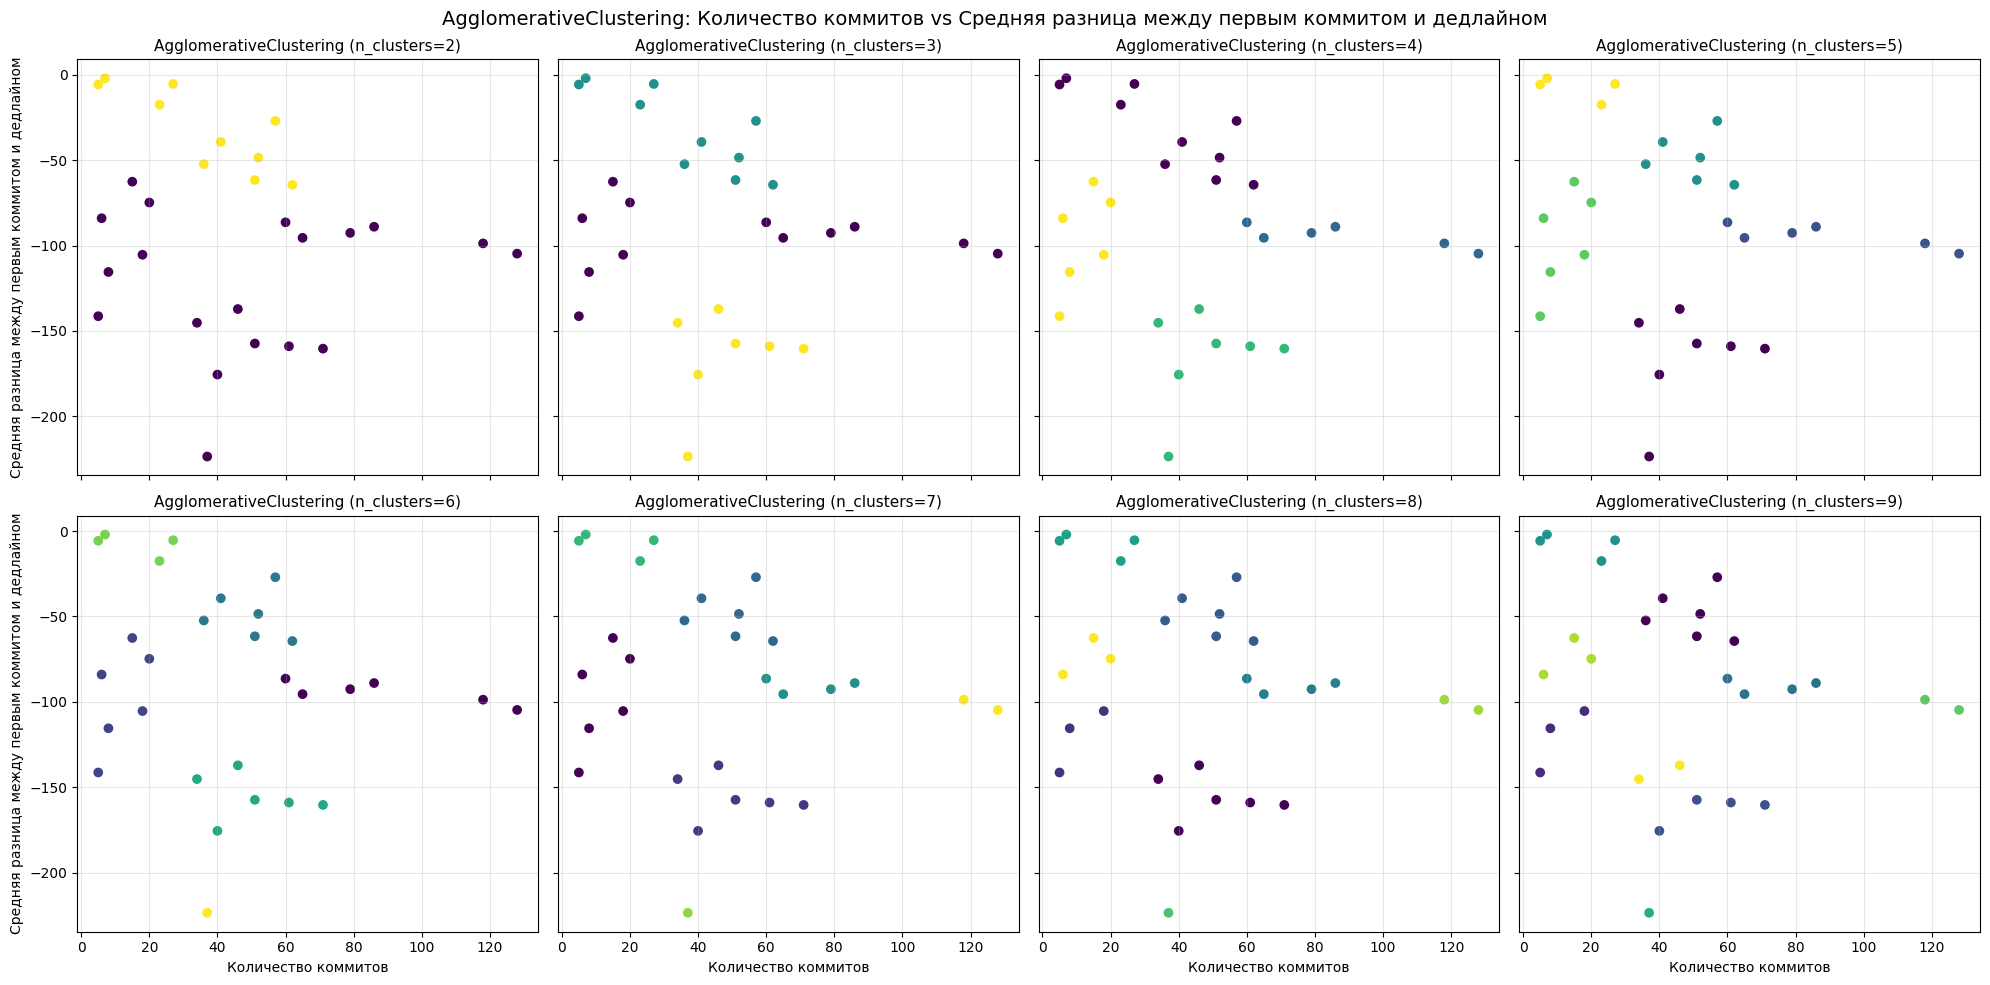

In [765]:
n_clusters_values = range(2, 10)

fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

for i, n_clusters in enumerate(n_clusters_values):
    ax = axes.flatten()[i]
    row, col = divmod(i, 4)

    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit_predict(df_clustering)

    ax.scatter(df_clustering['num_commits'], df_clustering['AVG(diff)'],
               c=labels, cmap='viridis')
    ax.set_title(f'AgglomerativeClustering (n_clusters={n_clusters})', fontsize=11)
    ax.grid(True, alpha=0.3)

    if col == 0:
        ax.set_ylabel('Средняя разница между первым коммитом и дедлайном', fontsize=10)
    if row == 1:
        ax.set_xlabel('Количество коммитов', fontsize=10)

plt.suptitle('AgglomerativeClustering: Количество коммитов vs Средняя разница между первым коммитом и дедлайном', fontsize=14)
plt.tight_layout()
plt.show()

In [766]:
agg_silhouette_scores = []

for n_clusters in n_clusters_values:
    labels = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward').fit_predict(df_clustering)
    score  = silhouette_score(df_clustering, labels)
    agg_silhouette_scores.append(score)
    print(f"n_clusters={n_clusters}: Silhouette={score}")

n_clusters=2: Silhouette=0.35902490572221984
n_clusters=3: Silhouette=0.3390493703444805
n_clusters=4: Silhouette=0.4448362750283643
n_clusters=5: Silhouette=0.46383015199381467
n_clusters=6: Silhouette=0.4527145606287827
n_clusters=7: Silhouette=0.4865808853184314
n_clusters=8: Silhouette=0.50779855565622
n_clusters=9: Silhouette=0.47576869039147557


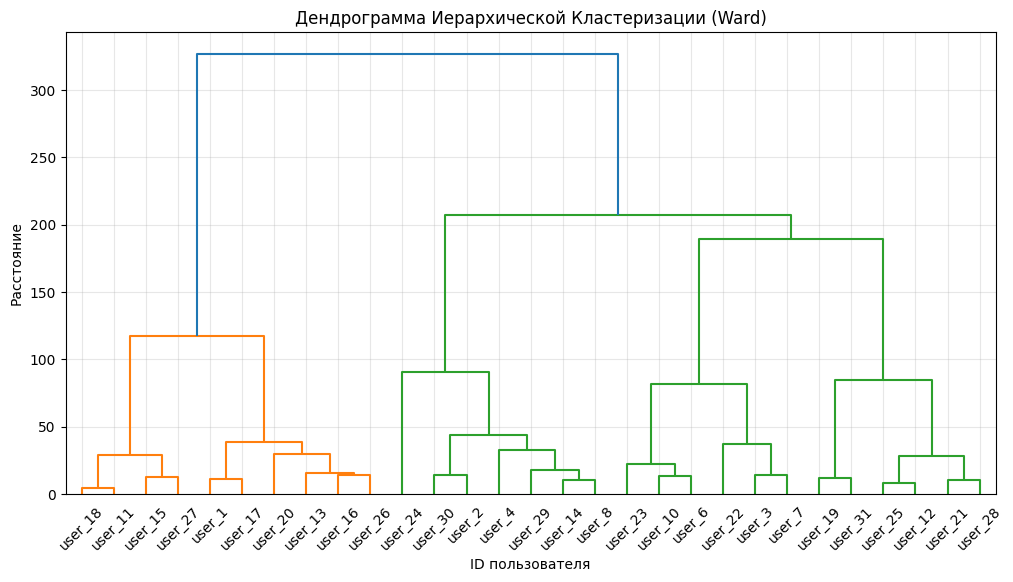

In [767]:
linkage_matrix = linkage(df_clustering, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(linkage_matrix, labels=df['uid'].values)
plt.title('Дендрограмма Иерархической Кластеризации (Ward)')
plt.xlabel('ID пользователя')
plt.ylabel('Расстояние')
plt.grid(True, alpha=0.3)

plt.show()

## 5. Function

Write a function that:
1. Takes as arguments: model class of clustering, its parameters, the name of the parameter for optimization, the range of the parameter values to try.
2. Tries different values from the given parameter range and calculates the `silhouette_score` for each value from the range.
3. Finds out the best value for the parameter in the range.
4. Returns two subplots:


- - the first shows how the `silhouette_score` changes depending on the value of the parameter,
- - the second visualizes the data on a `scatter plot` using the clustering model with the best value of the parameter.

In [768]:
def optimize_clustering_parameter(model_class, model_params, param_name, param_range):
    X_data = df_clustering
    param_range = list(param_range)

    group_name, group_values = None, None
    fixed_params = {}
    for k, v in model_params.items():
        if isinstance(v, (list, range)):
            group_name  = k
            group_values = list(v)
        else:
            fixed_params[k] = v

    if group_name is not None:
        best_score, best_val, best_gval, best_labels = -np.inf, None, None, None
        scores_by_group = {gv: [] for gv in group_values}

        for gv in group_values:
            for val in param_range:
                params = {**fixed_params, param_name: val, group_name: gv}
                try:
                    labels = model_class(**params).fit_predict(X_data)
                    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
                    if n_cl < 2:
                        continue
                    mask  = labels != -1
                    score = silhouette_score(X_data[mask], labels[mask])
                    scores_by_group[gv].append((val, score))
                    if score > best_score:
                        best_score, best_val, best_gval, best_labels = score, val, gv, labels
                except Exception as e:
                    print(f"{param_name}={val}, {group_name}={gv}: {e}")

        if best_labels is None:
            print("Нет результатов.")
            return None, None, None

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        cmap = plt.get_cmap('tab10')
        for idx, gv in enumerate(group_values):
            pairs = scores_by_group[gv]
            if not pairs:
                continue
            xs, ys = zip(*pairs)
            ax1.plot(xs, ys, 'o-', color=cmap(idx), linewidth=2, markersize=5,
                     label=f'{group_name}={gv}')

        ax1.axvline(best_val, color='red', linestyle='--', linewidth=1.5,
                    label=f'Лучшее: {param_name}={best_val}, {group_name}={best_gval}')
        title1 = f'{model_class.__name__}: Silhouette vs {param_name}\n(группировка по {group_name})'
        title2 = f'Лучшее: {param_name}={best_val}, {group_name}={best_gval}\nSilhouette={best_score}'

    else:
        scores, valid_params, valid_labels = [], [], []

        for val in param_range:
            params = {**fixed_params, param_name: val}
            try:
                labels = model_class(**params).fit_predict(X_data)
                n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
                if n_cl < 2:
                    continue
                mask  = labels != -1
                score = silhouette_score(X_data[mask], labels[mask])
                scores.append(score)
                valid_params.append(val)
                valid_labels.append(labels)
            except Exception as e:
                print(f"{param_name}={val}: {e}")

        if not scores:
            print("Нет результатов.")
            return None, None, None

        best_idx    = np.argmax(scores)
        best_val    = valid_params[best_idx]
        best_score  = scores[best_idx]
        best_labels = valid_labels[best_idx]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

        ax1.plot(valid_params, scores, 'bo-', linewidth=2, markersize=5)
        ax1.axvline(best_val, color='r', linestyle='--', label=f'Лучшее: {param_name}={best_val}')
        title1 = f'{model_class.__name__}: {param_name}'
        title2 = f'Лучшее: {param_name}={best_val}\nSilhouette={best_score}'

    ax1.set_xlabel(param_name, fontsize=12)
    ax1.set_ylabel('Silhouette Score', fontsize=12)
    ax1.set_title(title1, fontsize=12)
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    ax2.scatter(X_data.iloc[:, 0], X_data.iloc[:, 1], c=best_labels, cmap='viridis')
    ax2.set_xlabel('Количество коммитов', fontsize=12)
    ax2.set_ylabel('Средняя разница между первым коммитом и дедлайном', fontsize=12)
    ax2.set_title(title2, fontsize=12)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, best_val, best_score


KMeans best n_clusters=8, score=0.50779855565622


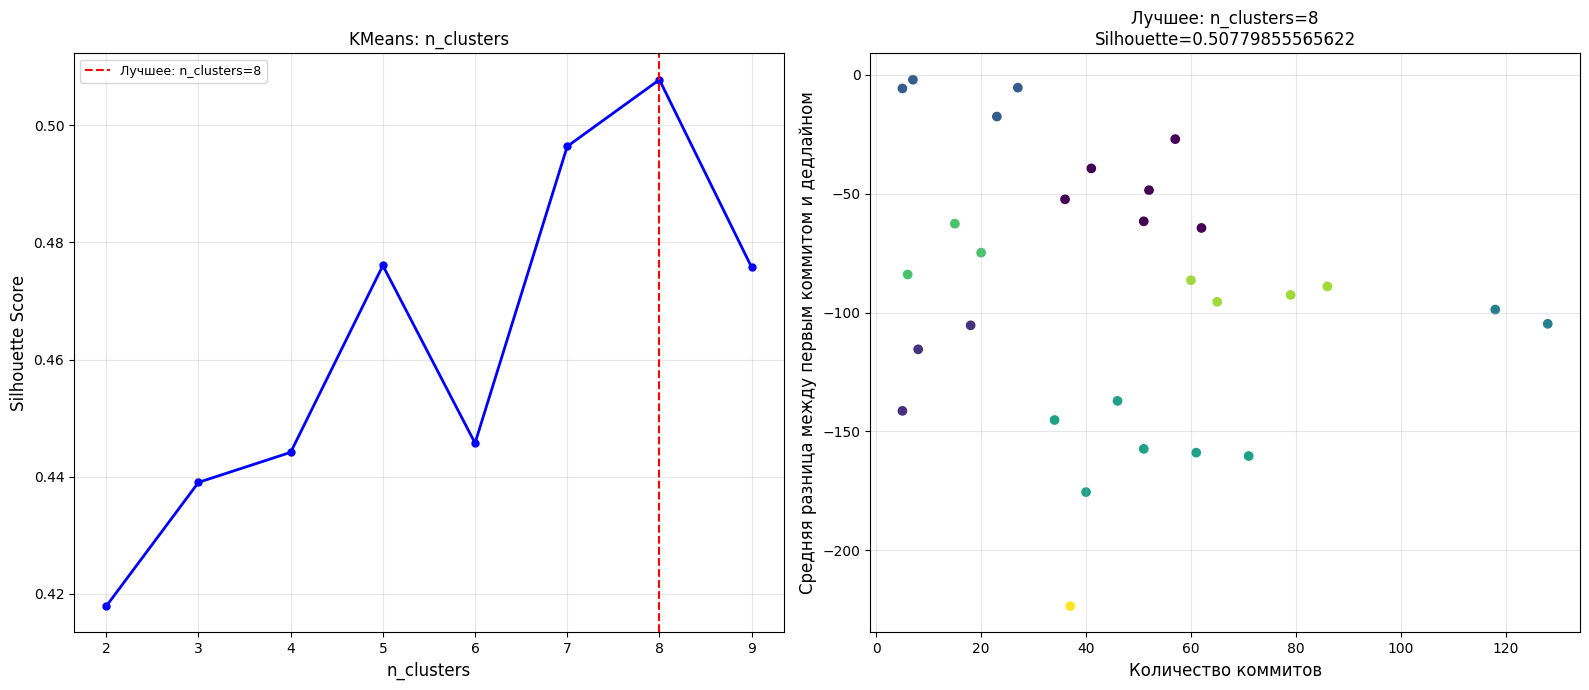

DBSCAN best eps=10, score=0.9480226534673492


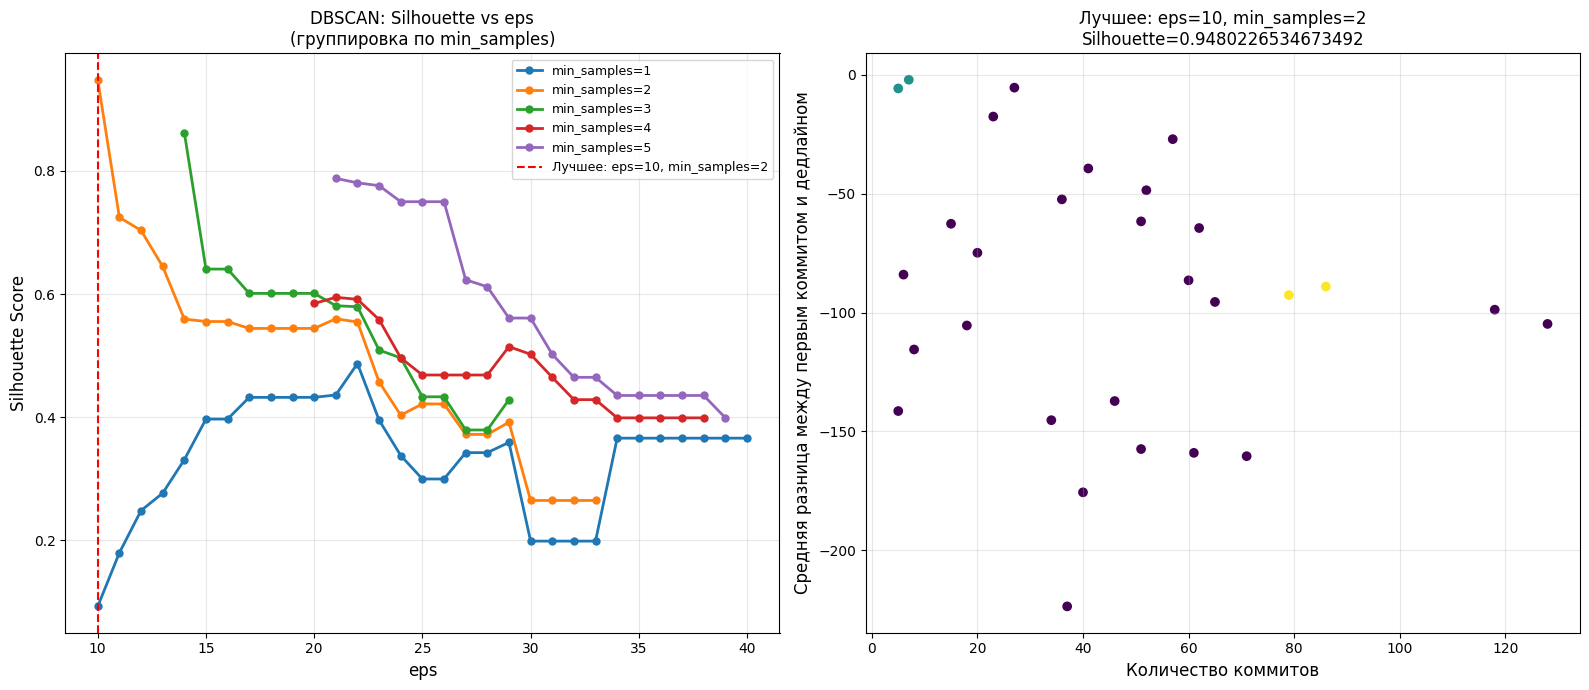

AgglomerativeClustering best n_clusters=8, score=0.50779855565622


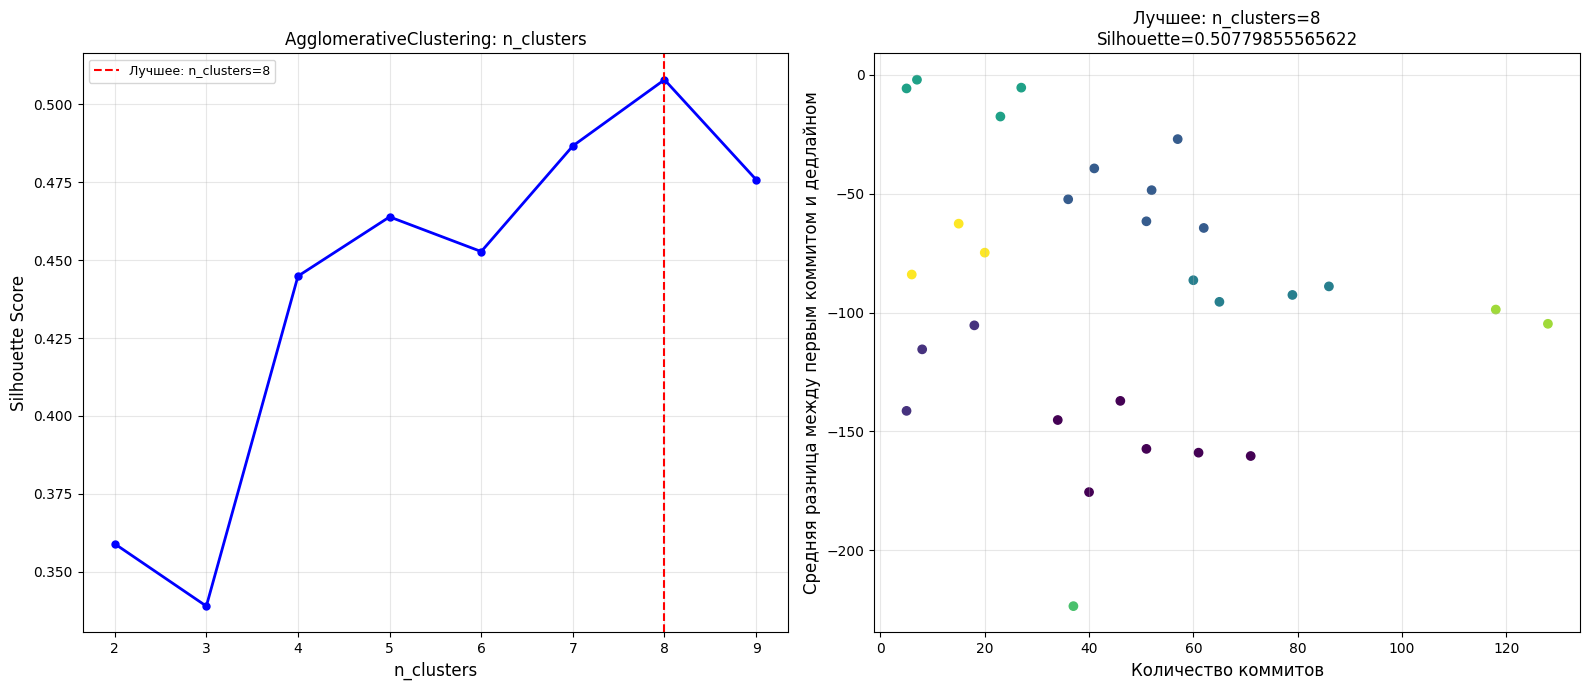

In [769]:
fig, best_k_opt, best_score_k = optimize_clustering_parameter(
    KMeans, {'random_state': 21, 'n_init': 10}, 'n_clusters', range(2, 10)
)
print(f"KMeans best n_clusters={best_k_opt}, score={best_score_k}")
plt.show()

fig, best_eps_opt, best_score_eps = optimize_clustering_parameter(
    DBSCAN, {'min_samples': range(1, 6)}, 'eps', range(10, 41)
)
print(f"DBSCAN best eps={best_eps_opt}, score={best_score_eps}")
plt.show()

fig, best_nc_opt, best_score_agg = optimize_clustering_parameter(
    AgglomerativeClustering, {'linkage': 'ward'}, 'n_clusters', range(2, 10)
)
print(f"AgglomerativeClustering best n_clusters={best_nc_opt}, score={best_score_agg}")
plt.show()